## Data Cleaning 

In [4]:
# cleaning
# imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
#create df
df = pd.read_csv("spx_eod_202301.txt")
pd.set_option('display.max_columns', None)
# drops columns that we may not need
df = df.drop(columns=["[QUOTE_UNIXTIME]", " [QUOTE_READTIME]", " [EXPIRE_UNIX]"])
# rename for easier use in future
df = df.rename(columns={
    " [QUOTE_DATE]" : "Quote_Date", 
    " [EXPIRE_DATE]" : "Expire_Date",
    ' [QUOTE_TIME_HOURS]' : "Quote_Time_Hours",
    ' [UNDERLYING_LAST]' : "Underlying_Last",
    ' [DTE]' : "DTE",
    ' [C_DELTA]' : "C_Delta",
    ' [C_GAMMA]' : "C_Gamma", 
    ' [C_VEGA]' : "C_Vega", 
    ' [C_THETA]' : "C_Theta",
    ' [C_RHO]' : "C_Rho", 
    ' [C_IV]' : "C_IV",
    ' [C_VOLUME]' : "C_Volume",
    ' [C_LAST]' : "C_Last", 
    ' [C_SIZE]' : "C_Size", 
    ' [C_BID]' : "C_Bid", 
    ' [C_ASK]' : "C_Ask",
    ' [STRIKE]' : "Strike", 
    ' [P_BID]' : "P_Bid",
    ' [P_ASK]' : "P_Ask",
    ' [P_SIZE]' : "P_Size", 
    ' [P_LAST]' : "P_Last",
    ' [P_DELTA]' : "P_Delta", 
    ' [P_GAMMA]' : "P_Gamma", 
    ' [P_VEGA]' : "P_Vega", 
    ' [P_THETA]' : "P_Theta", 
    ' [P_RHO]' : "P_Rho",
    ' [P_IV]' : "P_IV", 
    ' [P_VOLUME]' : "P_Volume", 
    ' [STRIKE_DISTANCE]' : "Strike_Distance",
    ' [STRIKE_DISTANCE_PCT]' : "Strike_Distance_PCT"
})
df = df.drop(columns=["C_Delta", "C_Gamma", "C_Vega", "C_Theta", "C_Rho", "P_Delta", "P_Gamma", "P_Vega", "P_Theta", "P_Rho"])
# turn " " in implied volatility columns into missing values and then drop
df["P_IV"] = df["P_IV"].replace(" ", np.nan)
df["C_IV"] = df["C_IV"].replace(" ", np.nan)
df = df.dropna(subset=["C_IV", "P_IV"])
# convert string into float
df["P_IV"] = df["P_IV"].astype(float)
df["C_IV"] = df["C_IV"].astype(float)
# create new columns, separate the size into bid and ask, convert to int
df["C_Bid_Size"] = df["C_Size"].str.split("x").str.get(0).astype(float)
df["C_Ask_Size"] = df["C_Size"].str.split("x").str.get(1).astype(float)
df["P_Bid_Size"] = df["P_Size"].str.split("x").str.get(0).astype(float)
df["P_Ask_Size"] = df["P_Size"].str.split("x").str.get(1).astype(float)
# since new columns were made we can drop original C_Size and P_Size
df = df.drop(columns = ["C_Size", "P_Size"])
df["C_Mid_Price"] = (df["C_Bid"] + df["C_Ask"]) / 2 
df["P_Mid_Price"] = (df["P_Bid"] + df["P_Ask"]) / 2 
# replace missing with zero and convert to float value 
df["C_Volume"] = df["C_Volume"].replace(" ", 0)
df["P_Volume"] = df["P_Volume"].replace(" ", 0)
df["C_Volume"] = df["C_Volume"].astype(float)
df["P_Volume"] = df["P_Volume"].astype(float)
# create moneyness column
df["Moneyness"] = df["Strike"] / df["Underlying_Last"]
# keep values where moneyness in range 0.8 to 1.2
df = df[(df["Moneyness"] > 0.8) & (df["Moneyness"] < 1.2)]

In [5]:
# available quote dates
df["Quote_Date"].unique()

array([' 2023-01-04', ' 2023-01-05', ' 2023-01-06', ' 2023-01-09',
       ' 2023-01-10', ' 2023-01-11', ' 2023-01-12', ' 2023-01-13',
       ' 2023-01-17', ' 2023-01-18', ' 2023-01-19', ' 2023-01-20',
       ' 2023-01-23', ' 2023-01-24', ' 2023-01-25', ' 2023-01-26',
       ' 2023-01-27', ' 2023-01-30', ' 2023-01-31'], dtype=object)

In [6]:
# available expiry dates
df["Expire_Date"].unique()

array([' 2023-01-04', ' 2023-01-05', ' 2023-01-06', ' 2023-01-09',
       ' 2023-01-10', ' 2023-01-11', ' 2023-01-12', ' 2023-01-13',
       ' 2023-01-17', ' 2023-01-18', ' 2023-01-19', ' 2023-01-20',
       ' 2023-01-23', ' 2023-01-24', ' 2023-01-25', ' 2023-01-26',
       ' 2023-01-27', ' 2023-01-30', ' 2023-01-31', ' 2023-02-01',
       ' 2023-02-02', ' 2023-02-03', ' 2023-02-06', ' 2023-02-10',
       ' 2023-02-17', ' 2023-02-24', ' 2023-02-28', ' 2023-03-17',
       ' 2023-03-31', ' 2023-04-21', ' 2023-04-28', ' 2023-05-19',
       ' 2023-05-31', ' 2023-06-16', ' 2023-06-30', ' 2023-07-21',
       ' 2023-08-18', ' 2023-09-15', ' 2023-09-29', ' 2023-10-20',
       ' 2023-11-17', ' 2023-12-15', ' 2023-12-29', ' 2024-01-19',
       ' 2024-03-15', ' 2024-06-21', ' 2024-12-20', ' 2025-12-19',
       ' 2026-12-18', ' 2027-12-17', ' 2023-02-13', ' 2023-02-07',
       ' 2023-02-08', ' 2023-02-09', ' 2023-03-03', ' 2023-02-14',
       ' 2023-02-15', ' 2023-02-16', ' 2023-02-27', ' 2024-02-

## Call Price Random Forest Model

In [2]:
x = df[["Underlying_Last", "DTE", "Strike", "C_IV"]]
y = df["C_Mid_Price"]
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=42
)
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf.fit(x_train, y_train)
y_test_pred = rf.predict(x_test)

In [3]:
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R²:", r2_score(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

MAE: 2.5020001630679243
R²: 0.9995946971358004
RMSE: 4.775148766502873


In [7]:
def random_forest_graph(quote_date, expire_date):
    quote_date = " " + quote_date
    expire_date = " " + expire_date  
    filtered = df[(df["Quote_Date"] == quote_date) & (df["Expire_Date"] == expire_date)]
    x_plot = filtered[["Underlying_Last", "DTE", "Strike", "C_IV"]]
    filtered["y_pred"] = rf.predict(x_plot)
    filtered = filtered.sort_values("Strike")
    plt.figure(figsize=(10, 5))
    plt.plot(filtered["Strike"], filtered["C_Mid_Price"], label="Actual")
    plt.plot(filtered["Strike"], filtered["y_pred"], label="Predicted", color="red")
    plt.xlabel("Strike")
    plt.ylabel("Price (Call)")
    plt.title("Actual vs Predicted Price (Same Quote and Expiry Day)")
    plt.legend()
    plt.show()

C:\Users\maxwe\AppData\Local\Temp\ipykernel_20832\4251658377.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["y_pred"] = rf.predict(x_plot)


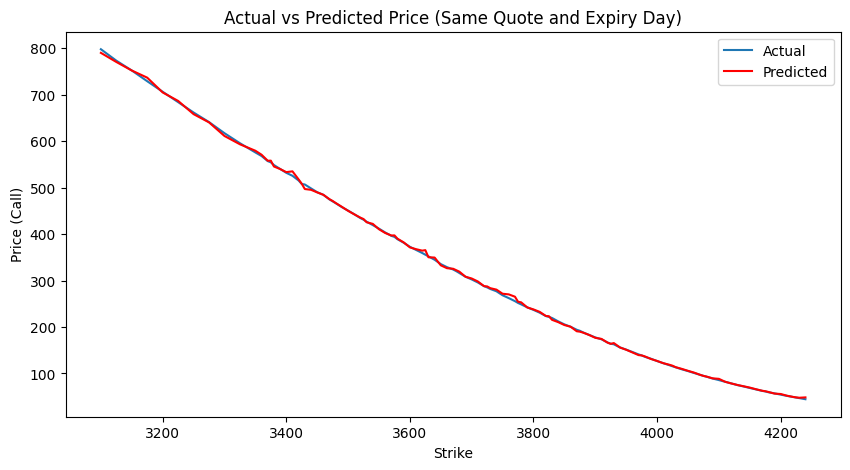

In [8]:
# use available dates from above, enter in format: "2023-xx-xx"
random_forest_graph("2023-01-04", "2023-04-28")

## Call Price XGB Model

In [9]:
a = df[["Underlying_Last", "DTE", "Strike", "C_IV"]]
b = df["C_Mid_Price"]
a_train, a_test, b_train, b_test = train_test_split(
    a,
    b,
    test_size=0.25,
    random_state=42
)
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.75,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb.fit(a_train, b_train)
b_test_pred = xgb.predict(a_test)

In [10]:
print("MAE:", mean_absolute_error(b_test, b_test_pred))
print("R²:", r2_score(b_test, b_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(b_test, b_test_pred)))

MAE: 6.65242128714113
R²: 0.9983922885661395
RMSE: 9.510451169691574


In [11]:
def xgboost_graph(quote_date, expire_date):
    quote_date = " " + quote_date
    expire_date = " " + expire_date  
    filtered = df[(df["Quote_Date"] == quote_date) & (df["Expire_Date"] == expire_date)]
    x_plot = filtered[["Underlying_Last", "DTE", "Strike", "C_IV"]]
    filtered["y_pred"] = xgb.predict(x_plot)
    filtered = filtered.sort_values("Strike")
    plt.figure(figsize=(10, 5))
    plt.plot(filtered["Strike"], filtered["C_Mid_Price"], label="Actual")
    plt.plot(filtered["Strike"], filtered["y_pred"], label="Predicted", color="red")
    plt.xlabel("Strike")
    plt.ylabel("Price (Call)")
    plt.title("Actual vs Predicted Price (Same Quote and Expiry Day)")
    plt.legend()
    plt.show()

C:\Users\maxwe\AppData\Local\Temp\ipykernel_20832\103844913.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["y_pred"] = xgb.predict(x_plot)


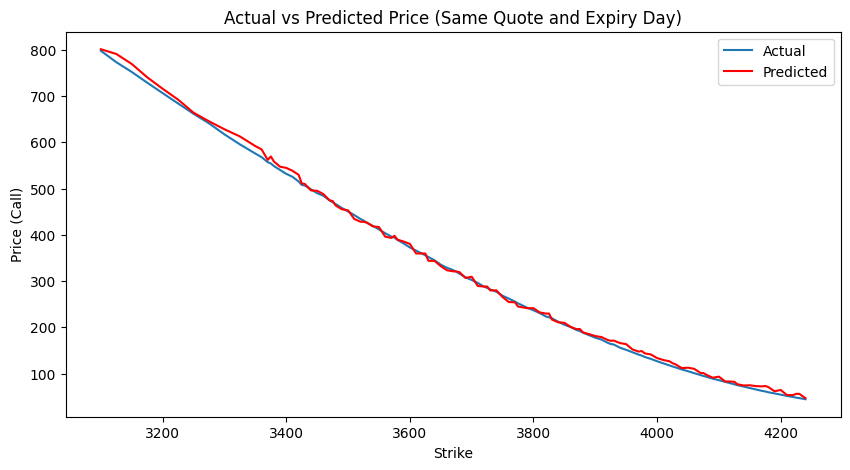

In [12]:
# use available dates from above, enter in format: "2023-xx-xx"
xgboost_graph("2023-01-04", "2023-04-28")